# 05 Explaining the model with LIME and SHAP

CSE 4889 Machine Learning: Explainable Multi-Label Hate Speech Detection in Transliterated Bangla

We load the trained model and use LIME and SHAP to see which words made it decide that a comment is hate or not. We do this for a fixed set of 8 test comments and save one highlighted-words figure per comment.

Runtime: T4 GPU (about 5 minutes).

## Install LIME

SHAP is already in Colab, but LIME is not.

In [1]:
!pip install -q lime

## Mount Google Drive

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Imports, paths and seed

The model code is in src/model.py, and the LIME and SHAP code in src/explainability/explain.py, because the rationale notebook uses the same functions later.

In [3]:
import os
import re
import sys
import json
import random
from datetime import datetime
from importlib.metadata import version

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from matplotlib.colors import to_rgb
from transformers import AutoTokenizer

BASE = '/content/drive/MyDrive/ML_Project'
SEED = 42
NOTEBOOK_NAME = '05_explainability.ipynb'
PROC_DIR = os.path.join(BASE, 'data', 'processed')
FIG_DIR = os.path.join(BASE, 'results', 'figures')
TAB_DIR = os.path.join(BASE, 'results', 'tables')
REP_DIR = os.path.join(BASE, 'results', 'evaluation_reports')
CKPT_DIR = os.path.join(BASE, 'results', 'model_checkpoints')
ASSETS_PATH = os.path.join(BASE, 'results', 'ASSETS.md')
sys.path.append(os.path.join(BASE, 'src'))
from model import load_trained, CATEGORIES
from explainability.explain import make_predict_fn, lime_word_weights, shap_word_weights, top_words

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

Device: cuda


## Helper functions

The same helpers as before: save tables as CSV and LaTeX, and add files to ASSETS.md.

In [4]:
def save_table(df, name, tex_df=None, float_format='%.2f'):
    df.to_csv(os.path.join(TAB_DIR, f'{name}.csv'), index=False)
    (df if tex_df is None else tex_df).to_latex(os.path.join(TAB_DIR, f'{name}.tex'), index=False,
                                                escape=True, float_format=float_format, na_rep='--')
    print('Saved:', name, '(.csv and .tex)')

def register_asset(asset_id, file_name, what, notebook, section, caption):
    row = f'| {asset_id} | {file_name} | {what} | {notebook} | {section} | {caption} |'
    with open(ASSETS_PATH, encoding='utf-8') as f:
        lines = f.read().splitlines()
    lines = [l for l in lines if not l.startswith(f'| {asset_id} |')]
    lines.append(row)
    with open(ASSETS_PATH, 'w', encoding='utf-8') as f:
        f.write('\n'.join(lines) + '\n')
    print('Registered', asset_id, '->', file_name)

SPACE_RE = re.compile(r'\s+')
def ascii_short(s, n=60):
    s = SPACE_RE.sub(' ', str(s).encode('ascii', 'ignore').decode()).strip()
    return s if len(s) <= n else s[:n - 3].rstrip() + '...'

## Load the trained model

We rebuild the model from model_config.json and load best_model.pt from the training notebook. We also re-check it on 64 test comments against the saved test predictions, to make sure we loaded the right model.

In [5]:
with open(os.path.join(CKPT_DIR, 'model_config.json')) as f:
    cfg = json.load(f)
tokenizer = AutoTokenizer.from_pretrained(cfg['model_name'])
model = load_trained(cfg['model_name'], os.path.join(CKPT_DIR, cfg['weights_file']), device)
predict_hate = make_predict_fn(model, tokenizer, cfg['max_length'], device)
BIN_THR = cfg['binary_threshold']

test_df = pd.read_csv(os.path.join(PROC_DIR, 'test.csv'), keep_default_na=False)
saved = pd.read_csv(os.path.join(REP_DIR, 'test_predictions.csv'))
check = predict_hate(test_df['clean_text'].tolist()[:64])
diff = np.abs(check - saved['p_hate'].values[:64]).max()
print(f'Largest difference from saved predictions: {diff:.4f}')
assert diff < 0.02, 'Loaded model does not match the saved predictions'

Largest difference from saved predictions: 0.0000


## Pick the comments to explain

We use a fixed rule instead of picking by hand, so the examples are not cherry-picked. Only comments with 4 to 20 words are used, so the figures stay readable.
- 5 correctly found hate comments, one each from Political, Religious, Gender, Personal Offense and Abusive/Violence (chosen randomly with seed 42),
- 1 hate comment the model missed (false negative),
- 1 normal comment it wrongly flagged (false positive),
- 1 normal comment it got right (true negative).

If a category has no suitable comment, it is skipped.

In [6]:
df = test_df.merge(saved.drop(columns=['Label']), on='comment_id')
cand = df[df['word_count'].between(4, 20)]

picked = []
for cat in ['Political', 'Religious', 'Gender', 'Personal Offense', 'Abusive/Violence']:
    pool = cand[(cand['Label'] == 1) & (cand['pred_hate'] == 1) & (cand[cat] == 1)
                & ~cand['comment_id'].isin([p[1] for p in picked])]
    if len(pool):
        picked.append((f'Hate, found ({cat})', pool.sample(1, random_state=SEED)['comment_id'].iloc[0]))
for kind, mask in [('Hate, missed', (cand['Label'] == 1) & (cand['pred_hate'] == 0)),
                   ('Non-hate, wrongly flagged', (cand['Label'] == 0) & (cand['pred_hate'] == 1)),
                   ('Non-hate, correct', (cand['Label'] == 0) & (cand['pred_hate'] == 0))]:
    picked.append((kind, cand[mask].sample(1, random_state=SEED)['comment_id'].iloc[0]))

chosen = df.set_index('comment_id').loc[[p[1] for p in picked]].reset_index()
chosen.insert(1, 'Case', [p[0] for p in picked])
chosen[['comment_id', 'Case', 'clean_text', 'p_hate']]

,comment_id,Case,clean_text,p_hate
0,test_01167,"Hate, found (Political)",Sontrrasi busted durniti bajj khoni president ...,0.843509
1,test_02428,"Hate, found (Religious)",dalalier Krishna Dalali Krishna,0.877687
2,test_02972,"Hate, found (Gender)",Egular theke dhaka sohorer magirao smart ase k...,0.964187
3,test_03181,"Hate, found (Personal Offense)",Khankir polar kaner niche ekta marte parle pol...,0.980766
4,test_02591,"Hate, found (Abusive/Violence)",Akhon bachar somoy aise. Ar vab chodau. Gopppo...,0.826712
5,test_01002,"Hate, missed",Tui kothay salar bata dasa sso,0.475270
6,test_00575,"Non-hate, wrongly flagged",Aho vatija.. Samne aho.... tumi to ekta... Fut...,0.627723
7,test_01133,"Non-hate, correct",Marbe kano apnader desh e to low ache,0.066327


## Run LIME and SHAP

Both methods explain the model's probability of hate and give every word a score. A positive score means the word pushes the comment towards hate, and a negative score pushes it towards non-hate.

- LIME removes random words many times (1,000 versions of each comment), watches how the probability changes, and fits a simple linear model to that.
- SHAP (partition explainer, 500 evaluations) shares the prediction out among the words in a fair way, based on Shapley values from game theory.

Words are the pieces between spaces, the same as in the human rationale sheet later, so the scores can be compared word by word. Both use seed 42.

In [7]:
results = []
for _, row in chosen.iterrows():
    text = row['clean_text']
    words, lime_w = lime_word_weights(text, predict_hate, num_samples=1000, seed=SEED)
    _, shap_w, shap_base = shap_word_weights(text, predict_hate, max_evals=500, seed=SEED)
    results.append({'comment_id': row['comment_id'], 'case': row['Case'], 'text': text, 'words': words,
                    'lime': lime_w.tolist(), 'shap': shap_w.tolist(), 'shap_base': shap_base,
                    'p_hate': float(row['p_hate']), 'label': int(row['Label'])})
    print(row['comment_id'], 'done')

test_01167 done
test_02428 done
test_02972 done
test_03181 done
test_02591 done
test_01002 done
test_00575 done
test_01133 done


## Drawing the highlighted words

Each figure shows the comment twice, once coloured by LIME and once by SHAP. Red words push towards hate, blue words push towards non-hate, and a stronger colour means a bigger effect. Colours are scaled separately for each method, because LIME and SHAP scores are on different scales.

Matplotlib can't draw emoji, so they are left out of the picture. A word that is only emoji is shown as [emoji].

In [8]:
RED, BLUE, INK, MUTED = '#e34948', '#2a78d6', '#0b0b0b', '#52514e'

def shade(hex_color, strength):
    rgb = np.array(to_rgb(hex_color))
    a = 0.85 * min(1.0, strength)
    return tuple((1 - a) * np.ones(3) + a * rgb)

def display_word(w):
    s = w.encode('ascii', 'ignore').decode()
    return s if s else '[emoji]'

def highlight_panel(ax, words, weights, label):
    ax.axis('off')
    fig = ax.figure
    fig.canvas.draw()
    renderer = fig.canvas.get_renderer()
    line_h = (8 * 2.3 * fig.dpi / 72) / ax.bbox.height
    gap = (4 * fig.dpi / 72) / ax.bbox.width
    ax.text(0, 1, label, transform=ax.transAxes, fontsize=8, fontweight='bold', va='top', color=INK)
    m = np.abs(weights).max() or 1.0
    x, y = 0.0, 1 - line_h
    for w, v in zip(words, weights):
        box = dict(boxstyle='round,pad=0.25', edgecolor='none',
                   facecolor=shade(RED if v > 0 else BLUE, abs(v) / m))
        t = ax.text(x, y, display_word(w), transform=ax.transAxes, fontsize=8, va='top',
                    color=INK, bbox=box)
        width = t.get_window_extent(renderer=renderer).width / ax.bbox.width
        if x > 0 and x + width > 1:
            x, y = 0.0, y - line_h
            t.set_position((x, y))
        x += width + gap

def explanation_figure(r):
    chars = sum(len(display_word(w)) + 2 for w in r['words'])
    lines = int(np.ceil(chars / 90))
    panel_h = 0.3 + 0.3 * lines
    fig = plt.figure(figsize=(7.0, 0.45 + 2 * panel_h + 0.25))
    gs = fig.add_gridspec(4, 1, height_ratios=[0.45, panel_h, panel_h, 0.25], hspace=0.1)
    head = fig.add_subplot(gs[0]); head.axis('off')
    true = 'Hate' if r['label'] == 1 else 'Non-hate'
    pred = 'Hate' if r['p_hate'] >= BIN_THR else 'Non-hate'
    head.text(0, 0.9, f"{r['comment_id']}   True: {true}   Predicted: {pred} (P(hate) = {r['p_hate']:.2f})",
              fontsize=8, color=INK, va='top', transform=head.transAxes)
    highlight_panel(fig.add_subplot(gs[1]), r['words'], np.array(r['lime']), '(a) LIME')
    highlight_panel(fig.add_subplot(gs[2]), r['words'], np.array(r['shap']), '(b) SHAP')
    foot = fig.add_subplot(gs[3]); foot.axis('off')
    foot.text(0, 0.5, 'Red: pushes towards hate.  Blue: pushes towards non-hate.  Darker = stronger.',
              fontsize=7, color=MUTED, va='center', transform=foot.transAxes)
    return fig

## Save one figure per comment (F07)

Each figure is saved as fig_07_explain_<comment id>.png at 300 dpi and added to ASSETS.md.

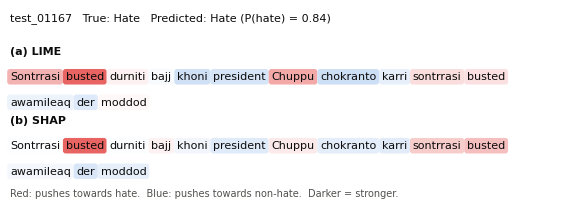

Registered F07.1 -> figures/fig_07_explain_test_01167.png


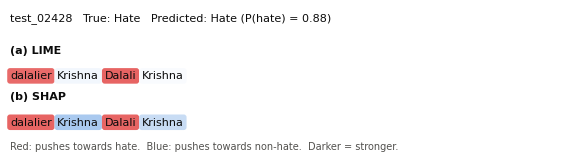

Registered F07.2 -> figures/fig_07_explain_test_02428.png


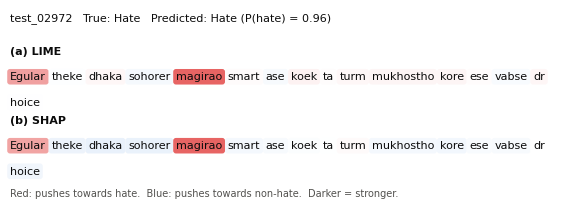

Registered F07.3 -> figures/fig_07_explain_test_02972.png


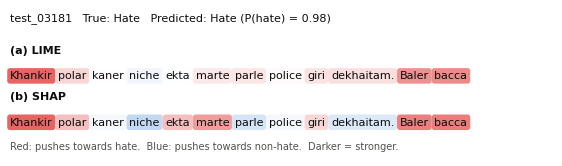

Registered F07.4 -> figures/fig_07_explain_test_03181.png


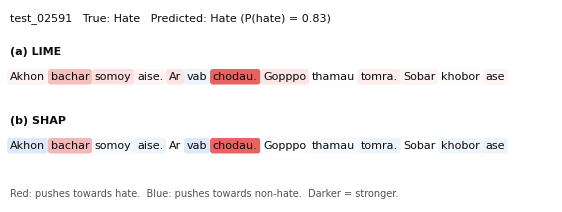

Registered F07.5 -> figures/fig_07_explain_test_02591.png


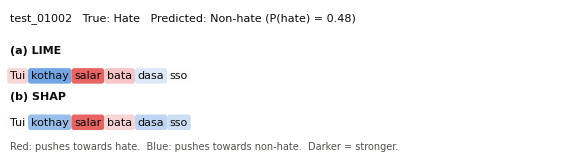

Registered F07.6 -> figures/fig_07_explain_test_01002.png


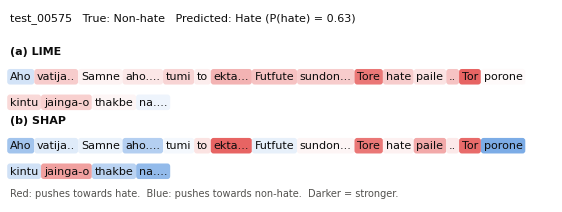

Registered F07.7 -> figures/fig_07_explain_test_00575.png


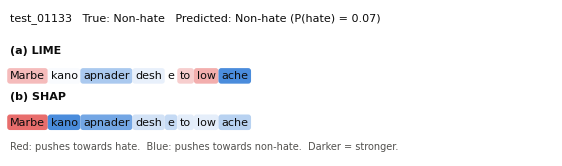

Registered F07.8 -> figures/fig_07_explain_test_01133.png


In [9]:
for k, r in enumerate(results, start=1):
    fig = explanation_figure(r)
    name = f"fig_07_explain_{r['comment_id']}.png"
    fig.savefig(os.path.join(FIG_DIR, name), dpi=300, bbox_inches='tight', facecolor='white')
    plt.show()
    register_asset(f'F07.{k}', f'figures/{name}',
                   f"LIME and SHAP word highlights for {r['comment_id']} ({r['case']})",
                   NOTEBOOK_NAME, 'V. Results (explanation examples)',
                   f"Fig. X. LIME (a) and SHAP (b) word attributions for test comment {r['comment_id']} ({r['case'].lower()}). "
                   'Red words push the prediction towards hate and blue words towards non-hate.')

## Table of the explained comments (T16)

For each comment: the case, the text, the true categories, P(hate), the top 3 words pushing towards hate for LIME and for SHAP, and how many of those top 3 words the two methods share. A low overlap means the two methods disagree about why the model decided.

In [10]:
def true_categories(cid):
    row = test_df.set_index('comment_id').loc[cid]
    names = [c for c in CATEGORIES if row[c] == 1]
    return ', '.join(names) if names else '-'

rows = []
for r in results:
    lime_top = top_words(r['words'], r['lime'])
    shap_top = top_words(r['words'], r['shap'])
    r['top3_overlap'] = len(set(lime_top) & set(shap_top)) / 3
    rows.append({'ID': r['comment_id'], 'Case': r['case'], 'Text': r['text'],
                 'True categories': true_categories(r['comment_id']), 'P(hate)': r['p_hate'],
                 'Top LIME words': ', '.join(r['words'][i] for i in lime_top) or '-',
                 'Top SHAP words': ', '.join(r['words'][i] for i in shap_top) or '-',
                 'Top-3 overlap': r['top3_overlap']})
explained = pd.DataFrame(rows)
display(explained)

explained_tex = explained.copy()
for col in ['Text', 'Top LIME words', 'Top SHAP words']:
    explained_tex[col] = explained_tex[col].map(lambda s: ascii_short(s, 45))
save_table(explained, 'tab_16_explained_comments', tex_df=explained_tex)
register_asset('T16', 'tables/tab_16_explained_comments.csv (+ .tex)',
               'The 8 explained test comments with prediction, top LIME and SHAP words and their top-3 overlap',
               NOTEBOOK_NAME, 'V. Results (explanation examples)',
               'TABLE X. Test comments used for the explanation examples, with the three words that most increase the predicted hate probability under LIME and SHAP (text shortened; emoji removed).')
print(f"Mean top-3 overlap between LIME and SHAP: {explained['Top-3 overlap'].mean():.2f}")

,ID,Case,Text,True categories,P(hate),Top LIME words,Top SHAP words,Top-3 overlap
0,test_01167,"Hate, found (Political)",Sontrrasi busted durniti bajj khoni president ...,"Political, Personal Offense",0.843509,"busted, Chuppu, Sontrrasi","busted, busted, sontrrasi",0.333333
1,test_02428,"Hate, found (Religious)",dalalier Krishna Dalali Krishna,"Religious, Personal Offense",0.877687,"Dalali, dalalier","dalalier, Dalali",0.666667
2,test_02972,"Hate, found (Gender)",Egular theke dhaka sohorer magirao smart ase k...,"Gender, Personal Offense, Origin",0.964187,"magirao, Egular, koek","magirao, Egular, turm",0.666667
3,test_03181,"Hate, found (Personal Offense)",Khankir polar kaner niche ekta marte parle pol...,"Personal Offense, Abusive/Violence",0.980766,"Khankir, bacca, Baler","Khankir, bacca, Baler",1.000000
4,test_02591,"Hate, found (Abusive/Violence)",Akhon bachar somoy aise. Ar vab chodau. Gopppo...,"Personal Offense, Abusive/Violence",0.826712,"chodau., bachar, somoy","chodau., bachar",0.666667
5,test_01002,"Hate, missed",Tui kothay salar bata dasa sso,"Personal Offense, Abusive/Violence",0.475270,"salar, bata, Tui","salar, bata, Tui",1.000000
6,test_00575,"Non-hate, wrongly flagged",Aho vatija.. Samne aho.... tumi to ekta... Fut...,-,0.627723,"Tor, Tore, ekta...","ekta..., Tor, Tore",1.000000
7,test_01133,"Non-hate, correct",Marbe kano apnader desh e to low ache,-,0.066327,"low, Marbe, to",Marbe,0.333333


Saved: tab_16_explained_comments (.csv and .tex)
Registered T16 -> tables/tab_16_explained_comments.csv (+ .tex)
Mean top-3 overlap between LIME and SHAP: 0.71


## Save all word scores (M09)

Every word score for every comment goes into explanations_examples.json, along with the settings and library versions, so the figures can be redrawn without running LIME and SHAP again.

In [11]:
out = {
    'step': 'explain', 'notebook': NOTEBOOK_NAME, 'date': datetime.now().isoformat(timespec='seconds'),
    'seed': SEED, 'model': cfg['model_name'], 'weights': cfg['weights_file'],
    'explained_output': 'binary head, probability of hate',
    'lime': {'version': version('lime'), 'num_samples': 1000, 'split': 'whitespace'},
    'shap': {'version': version('shap'), 'explainer': 'partition', 'max_evals': 500,
             'masking': 'word removed', 'split': 'whitespace'},
    'mean_top3_overlap': float(explained['Top-3 overlap'].mean()),
    'comments': results,
}
path = os.path.join(REP_DIR, 'explanations_examples.json')
with open(path, 'w', encoding='utf-8') as f:
    json.dump(out, f, indent=2, ensure_ascii=False)
print('Saved:', path)
register_asset('M09', 'evaluation_reports/explanations_examples.json',
               'Word-level LIME and SHAP scores for the 8 explained comments, with settings and versions',
               NOTEBOOK_NAME, 'IV. Methodology / V. Results',
               'Not a figure; source for the explanation figures and the LIME-SHAP overlap.')

Saved: /content/drive/MyDrive/ML_Project/results/evaluation_reports/explanations_examples.json
Registered M09 -> evaluation_reports/explanations_examples.json


## Summary

We explained 8 fixed test comments with LIME and SHAP, saved one highlighted figure per comment (F07.1 to F07.8), the table of comments and top words (T16), and all word scores (explanations_examples.json).

These pictures only show what the methods say. They don't prove the explanations are right. That is checked in the next notebook, where we compare them with words highlighted by people (plausibility) and test whether removing the top words really changes the prediction (faithfulness).

## Remember this

- What we did: used LIME and SHAP to show which words pushed the model towards hate or non-hate for 8 fixed test comments.
- Why: a moderator needs to see why a comment was flagged, not just the label.
- Key number: LIME and SHAP agree on 0.71 of their top 3 hate words on average (T16), and both put the clearly abusive words first in the obvious cases.